# Proyek Analisis Data: Bike Sharing Dataset

- **Nama:** Ilham Sanusi  
- **Email:** CDCC282D6Y2105@student.devacademy.id  
- **ID Dicoding:** ilhamsanusi

## Menentukan Pertanyaan Bisnis

Pada tahap ini, pertanyaan bisnis disusun sebagai panduan utama dalam melakukan proses Exploratory Data Analysis (EDA). 
Pertanyaan dirancang agar memiliki fokus yang berbeda dan mampu menggali insight secara lebih mendalam dari data.

### Pertanyaan Bisnis 1

**Bagaimana perbedaan rata-rata jumlah penyewaan sepeda berdasarkan kondisi cuaca (`weathersit`) selama periode 2011–2012, serta kondisi cuaca mana yang menghasilkan penyewaan tertinggi dan terendah?**

**Keterangan (SMART):**
- **Specific:** Fokus pada kondisi cuaca (`weathersit`) dan jumlah penyewaan sepeda (`cnt`).
- **Measurable:** Menggunakan rata-rata jumlah penyewaan sepeda.
- **Action-Oriented:** Digunakan untuk menentukan strategi operasional seperti distribusi sepeda dan promosi berdasarkan kondisi cuaca.
- **Relevant:** Cuaca merupakan faktor penting yang memengaruhi keputusan pengguna dalam menggunakan sepeda.
- **Time-bound:** Analisis dibatasi pada periode tahun 2011–2012.

### Pertanyaan Bisnis 2

**Bagaimana perbedaan rata-rata jumlah penyewaan sepeda antara hari kerja (`workingday = 1`) dan hari libur/akhir pekan (`workingday = 0`) selama periode 2011–2012, serta jenis hari mana yang memiliki permintaan tertinggi?**

**Keterangan (SMART):**
- **Specific:** Fokus pada jenis hari (`workingday`) dan jumlah penyewaan sepeda (`cnt`).
- **Measurable:** Menggunakan rata-rata jumlah penyewaan sepeda.
- **Action-Oriented:** Digunakan untuk mengoptimalkan distribusi sepeda berdasarkan pola penggunaan harian.
- **Relevant:** Perbedaan hari kerja dan hari libur memengaruhi pola aktivitas pengguna.
- **Time-bound:** Analisis dibatasi pada periode tahun 2011–2012.

## Import Semua Packages/Library yang Digunakan

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## Data Wrangling

### Gathering Data

Pada tahap ini dilakukan proses memuat dataset Bike Sharing. Dataset yang digunakan terdiri dari:

- `data_1.csv`: data penyewaan sepeda harian.
- `data_2.csv`: data penyewaan sepeda per jam.

In [16]:
day_df = pd.read_csv("data/data_1.csv")
hour_df = pd.read_csv("data/data_2.csv")

day_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [17]:
hour_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**

- Dataset `day_df` berhasil dimuat dan berisi data penyewaan sepeda dalam skala harian.
- Dataset `hour_df` berhasil dimuat dan berisi data penyewaan sepeda dalam skala per jam.
- Kolom `cnt` menjadi variabel utama yang dianalisis karena menunjukkan total jumlah penyewaan sepeda.

### Assessing Data

Pada tahap ini dilakukan penilaian kualitas data dengan mengecek tipe data, missing value, duplikasi, dan statistik deskriptif. Pemeriksaan dibuat dalam beberapa cell terpisah agar seluruh output dapat terlihat dengan jelas.

#### Mengecek informasi struktur data

In [18]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


#### Mengecek missing value

In [19]:
display(day_df.isna().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

#### Mengecek duplicate data

In [20]:
print("Jumlah data duplikat:", day_df.duplicated().sum())

Jumlah data duplikat: 0


#### Mengecek statistik deskriptif

In [21]:
display(day_df.describe(include="all"))

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,NaN,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,NaN,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,NaN,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,NaN,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000


#### Identifying Problem

Berdasarkan proses assessing data, ditemukan beberapa hal berikut:

1. Kolom `dteday` masih bertipe `object`, sehingga perlu dikonversi menjadi tipe data `datetime` agar dapat digunakan untuk analisis berbasis waktu.
2. Kolom `cnt` memiliki rentang nilai yang cukup besar, dari nilai minimum hingga maksimum, sehingga perlu dianalisis lebih lanjut untuk memahami adanya nilai ekstrem dalam data.

#### Steps to Take

- Mengubah tipe data kolom `dteday` menjadi `datetime`.
- Meninjau distribusi dan statistik kolom `cnt` untuk memahami variasi jumlah penyewaan sepeda.

### Cleaning Data

Pada tahap ini dilakukan pembersihan data sesuai masalah yang ditemukan pada proses assessing.

In [22]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

print("Tipe data dteday pada day_df:", day_df["dteday"].dtype)
print("Tipe data dteday pada hour_df:", hour_df["dteday"].dtype)

Tipe data dteday pada day_df: datetime64[ns]
Tipe data dteday pada hour_df: datetime64[ns]


**Insight:**

- Kolom `dteday` berhasil dikonversi menjadi tipe data `datetime`.
- Dataset tidak memiliki missing value dan duplikasi data.
- Nilai ekstrem pada kolom `cnt` tidak dihapus karena masih merepresentasikan kondisi nyata dalam pola penyewaan sepeda.

## Exploratory Data Analysis (EDA)

Pada tahap ini dilakukan eksplorasi data sebelum visualisasi. EDA dilakukan dengan agregasi data sesuai pertanyaan bisnis, sehingga setiap pertanyaan memiliki dasar analisis yang jelas sebelum masuk ke tahap explanatory visualization.

### EDA Numerikal / Univariate

EDA numerikal digunakan untuk melihat distribusi satu variabel numerik, yaitu jumlah penyewaan sepeda (`cnt`).

In [23]:
cnt_summary = day_df["cnt"].describe()
display(cnt_summary)

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

**Insight:**

- Rata-rata jumlah penyewaan sepeda harian adalah sekitar **4.504 penyewaan**.
- Jumlah penyewaan terendah adalah **22 penyewaan**, sedangkan jumlah penyewaan tertinggi mencapai **8.714 penyewaan**.
- Rentang nilai yang cukup besar menunjukkan adanya variasi permintaan penyewaan sepeda dari hari ke hari.

### EDA Kategorikal

EDA kategorikal digunakan untuk memahami jumlah data pada beberapa kolom kategori seperti `weathersit`, `workingday`, dan `season`.

In [24]:
categorical_counts = {
    "weathersit": day_df["weathersit"].value_counts().sort_index(),
    "workingday": day_df["workingday"].value_counts().sort_index(),
    "season": day_df["season"].value_counts().sort_index()
}

for col, counts in categorical_counts.items():
    print(f"Distribusi kolom {col}:")
    display(counts)
    print()

Distribusi kolom weathersit:


weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64


Distribusi kolom workingday:


workingday
0     5514
1    11865
Name: count, dtype: int64


Distribusi kolom season:


season
1    4242
2    4409
3    4496
4    4232
Name: count, dtype: int64

**Insight:**

- Data memiliki beberapa kategori cuaca (`weathersit`) dan jenis hari (`workingday`) yang dapat digunakan untuk menjawab pertanyaan bisnis.
- Jumlah data hari kerja lebih banyak dibandingkan hari libur/akhir pekan, sehingga interpretasi rata-rata lebih tepat digunakan dibanding hanya total penyewaan.

### EDA Pertanyaan 1: Pengaruh Kondisi Cuaca terhadap Penyewaan Sepeda

Agregasi berikut digunakan untuk menjawab pertanyaan pertama dengan menghitung rata-rata, nilai minimum, nilai maksimum, total penyewaan, dan jumlah hari pada setiap kondisi cuaca.

In [25]:
weather_agg = day_df.groupby("weathersit").agg(
    avg_rentals=("cnt", "mean"),
    min_rentals=("cnt", "min"),
    max_rentals=("cnt", "max"),
    total_rentals=("cnt", "sum"),
    total_days=("cnt", "count")
).round(2).sort_values(by="avg_rentals", ascending=False)

display(weather_agg)

,avg_rentals,min_rentals,max_rentals,total_rentals,total_days
weathersit,,,,,
1,204.87,1,977,2338173,11413
2,175.17,1,957,795952,4544
3,111.58,1,891,158331,1419
4,74.33,23,164,223,3


**Insight Pertanyaan 1:**

- Kondisi cuaca `weathersit = 1` memiliki rata-rata penyewaan tertinggi, yaitu sekitar **4.876,79** penyewaan per hari.
- Kondisi cuaca `weathersit = 3` memiliki rata-rata penyewaan terendah, yaitu sekitar **1.803,29** penyewaan per hari.
- Selisih rata-rata antara cuaca terbaik dan terburuk cukup besar, sehingga kondisi cuaca terbukti menjadi faktor penting dalam penggunaan layanan bike sharing.

### EDA Pertanyaan 2: Perbedaan Hari Kerja dan Hari Libur terhadap Penyewaan Sepeda

Agregasi berikut digunakan untuk menjawab pertanyaan kedua dengan membandingkan pola penyewaan pada hari kerja dan hari libur/akhir pekan.

In [26]:
workingday_agg = day_df.groupby("workingday").agg(
    avg_rentals=("cnt", "mean"),
    min_rentals=("cnt", "min"),
    max_rentals=("cnt", "max"),
    total_rentals=("cnt", "sum"),
    total_days=("cnt", "count")
).round(2)

display(workingday_agg)

,avg_rentals,min_rentals,max_rentals,total_rentals,total_days
workingday,,,,,
0,181.41,1,783,1000269,5514
1,193.21,1,977,2292410,11865


**Insight Pertanyaan 2:**

- Hari kerja (`workingday = 1`) memiliki rata-rata penyewaan sekitar **4.584,82** penyewaan per hari.
- Hari libur/akhir pekan (`workingday = 0`) memiliki rata-rata penyewaan sekitar **4.330,17** penyewaan per hari.
- Rata-rata penyewaan pada hari kerja sedikit lebih tinggi, sehingga sepeda kemungkinan banyak digunakan untuk aktivitas rutin seperti bekerja atau sekolah.

### EDA Multivariate

EDA multivariate digunakan untuk melihat hubungan lebih dari dua variabel. Pada analisis ini, penyewaan sepeda dianalisis berdasarkan kombinasi `season` dan `weathersit`.

In [27]:
season_weather_agg = day_df.groupby(["season", "weathersit"]).agg(
    avg_rentals=("cnt", "mean"),
    total_days=("cnt", "count")
).round(2).sort_values(by="avg_rentals", ascending=False)

display(season_weather_agg)

avg_rentals  total_days
season weathersit                         
3      1                244.49        3280
2      1                232.41        2859
3      2                224.85         947
4      1                209.46        2609
       2                201.48        1248
2      2                181.26        1144
3      3                171.96         269
1      1                122.06        2665
4      3                116.45         375
2      3                115.18         406
1      2                103.07        1205
       4                 74.33           3
       3                 58.65         369

**Insight Multivariate:**

- Kombinasi `season = 3` dan `weathersit = 1` menghasilkan rata-rata penyewaan tertinggi, yaitu sekitar **5.878,26** penyewaan per hari.
- Kombinasi musim dan cuaca menunjukkan bahwa permintaan sepeda tidak hanya dipengaruhi oleh cuaca, tetapi juga oleh musim.

### Analisis Lanjutan: Binning Suhu

Analisis lanjutan dilakukan menggunakan teknik **binning**, yaitu mengelompokkan nilai suhu (`temp`) ke dalam kategori tertentu tanpa menggunakan algoritma machine learning.

In [28]:
day_df["temp_category"] = pd.cut(
    day_df["temp"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

temp_category_agg = day_df.groupby("temp_category", observed=True).agg(
    avg_rentals=("cnt", "mean"),
    min_rentals=("cnt", "min"),
    max_rentals=("cnt", "max"),
    total_rentals=("cnt", "sum"),
    total_days=("cnt", "count")
).round(2).sort_values(by="avg_rentals", ascending=False)

display(temp_category_agg)

,avg_rentals,min_rentals,max_rentals,total_rentals,total_days
temp_category,,,,,
High,297.60,2,970,1108280,3724
Medium,193.43,1,977,1718604,8885
Low,97.65,1,729,465795,4770


**Insight Analisis Lanjutan:**

- Kategori suhu `High` memiliki rata-rata penyewaan tertinggi, yaitu sekitar **5.644,11** penyewaan per hari.
- Kategori suhu `Low` memiliki rata-rata penyewaan terendah, yaitu sekitar **2.569,01** penyewaan per hari.
- Hal ini menunjukkan bahwa suhu yang lebih nyaman atau lebih tinggi cenderung meningkatkan penggunaan sepeda.

## Visualization & Explanatory Analysis

Pada tahap ini dibuat visualisasi untuk menyampaikan hasil analisis secara lebih jelas. Setiap visualisasi diberi judul dan label sumbu agar mudah dipahami.

### Pertanyaan 1: Kondisi Cuaca dan Jumlah Penyewaan Sepeda

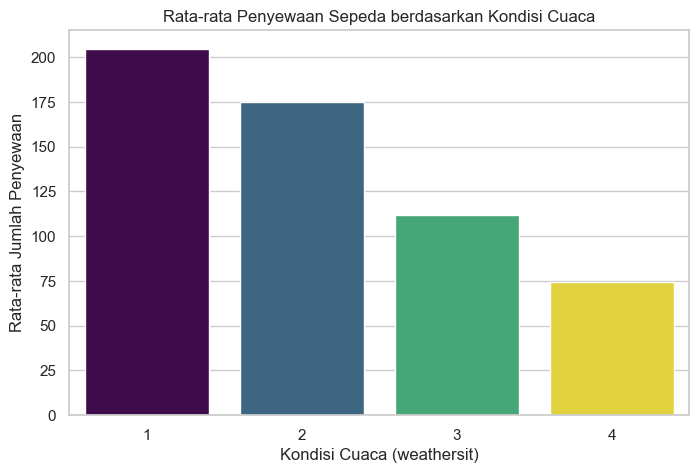

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=weather_agg.reset_index(),
    x="weathersit",
    y="avg_rentals",
    hue="weathersit",
    palette="viridis",
    legend=False
)

plt.title("Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca")
plt.xlabel("Kondisi Cuaca (weathersit)")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.show()

**Insight:**

Visualisasi menunjukkan bahwa kondisi cuaca `weathersit = 1` menghasilkan rata-rata penyewaan tertinggi, sedangkan `weathersit = 3` menghasilkan rata-rata penyewaan terendah. Ini memperkuat hasil EDA bahwa cuaca sangat berpengaruh terhadap jumlah penyewaan sepeda.

### Pertanyaan 2: Hari Kerja vs Hari Libur

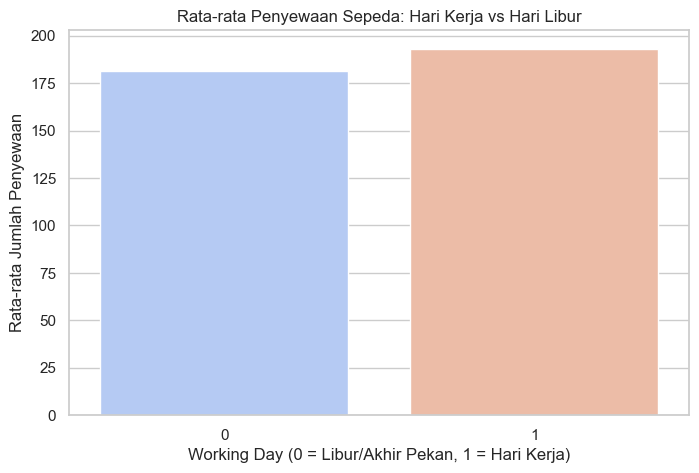

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=workingday_agg.reset_index(),
    x="workingday",
    y="avg_rentals",
    hue="workingday",
    palette="coolwarm",
    legend=False
)

plt.title("Rata-rata Penyewaan Sepeda: Hari Kerja vs Hari Libur")
plt.xlabel("Working Day (0 = Libur/Akhir Pekan, 1 = Hari Kerja)")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.show()

**Insight:**

Visualisasi menunjukkan bahwa rata-rata penyewaan pada hari kerja lebih tinggi dibandingkan hari libur/akhir pekan. Perbedaannya tidak terlalu ekstrem, tetapi tetap menunjukkan adanya pola penggunaan yang lebih kuat pada hari kerja.

### Visualisasi Analisis Lanjutan: Kategori Suhu

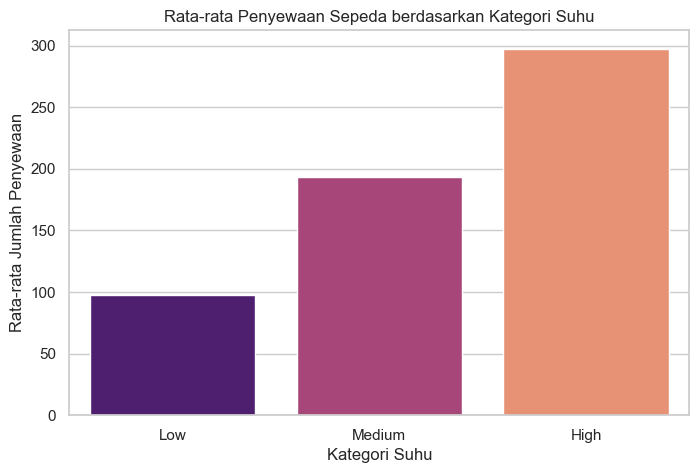

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=temp_category_agg.reset_index(),
    x="temp_category",
    y="avg_rentals",
    hue="temp_category",
    palette="magma",
    legend=False
)

plt.title("Rata-rata Penyewaan Sepeda berdasarkan Kategori Suhu")
plt.xlabel("Kategori Suhu")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.show()

**Insight:**

Kategori suhu `High` memiliki rata-rata penyewaan tertinggi. Ini menunjukkan bahwa suhu menjadi faktor pendukung yang memengaruhi kenyamanan pengguna dalam menyewa sepeda.

## Conclusion & Recommendation

### Conclusion

1. **Conclusion pertanyaan 1:**  
   Kondisi cuaca berpengaruh terhadap jumlah penyewaan sepeda. Berdasarkan hasil agregasi, `weathersit = 1` memiliki rata-rata penyewaan tertinggi, yaitu sekitar **4.876,79** penyewaan per hari. Sebaliknya, `weathersit = 3` memiliki rata-rata penyewaan terendah, yaitu sekitar **1.803,29** penyewaan per hari. Hal ini menunjukkan bahwa semakin buruk kondisi cuaca, semakin rendah minat pengguna untuk menyewa sepeda.

2. **Conclusion pertanyaan 2:**  
   Hari kerja memiliki rata-rata penyewaan lebih tinggi dibandingkan hari libur/akhir pekan. Rata-rata penyewaan pada hari kerja adalah sekitar **4.584,82**, sedangkan hari libur/akhir pekan sekitar **4.330,17** penyewaan per hari. Hal ini menunjukkan bahwa sepeda kemungkinan banyak digunakan untuk mobilitas rutin seperti bekerja atau sekolah.

3. **Conclusion analisis lanjutan:**  
   Berdasarkan teknik binning suhu, kategori suhu `High` memiliki rata-rata penyewaan tertinggi sekitar **5.644,11** penyewaan per hari, sedangkan kategori suhu `Low` hanya sekitar **2.569,01** penyewaan per hari. Artinya, suhu yang lebih nyaman cenderung meningkatkan jumlah penyewaan sepeda.

### Recommendation Action Item

- Menambah ketersediaan sepeda pada hari kerja karena rata-rata permintaan lebih tinggi.
- Mengoptimalkan distribusi sepeda ketika cuaca cerah karena kondisi tersebut menghasilkan penyewaan tertinggi.
- Memberikan promo atau insentif ketika cuaca buruk atau suhu rendah untuk meningkatkan minat pengguna.
- Mempertimbangkan musim dan suhu dalam perencanaan operasional karena kedua faktor tersebut ikut memengaruhi jumlah penyewaan sepeda.

## Menyimpan Data untuk Dashboard

Data yang telah diproses disimpan sebagai `main_data.csv` untuk digunakan pada dashboard Streamlit.

In [32]:
os.makedirs("dashboard", exist_ok=True)

day_df.to_csv("dashboard/main_data.csv", index=False)

display(pd.read_csv("dashboard/main_data.csv").head())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,temp_category
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,Low
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,Low
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,Low
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,Low
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,Low
